<a href="https://colab.research.google.com/gist/vuddameri/75212bfab7d98a9c75861243a9f8f272/thomas-algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><font color = 'blue'><center>Tridiagonal Matrix Algorithm (Thomas Algorithm)</center></font></h1>

<p > Sparse matrices are commonly encountered when finite difference and finite element methods are used to solve differential equations.  <font color='red'>A sparse matrix is a matrix where a majority of elements have zero values.</font>  The presence of a large number of zeros creates both challenges and opportunities when solving matrices.  The primary challenge arises when inverting a matrix using traditional methods.  However, for sparsity also helps reduce the data storage requirements and lead to simpler approaches to solve systems of equations involving sparse matrices.</p> 

<p> <font color='red'>A tridiagonal matrix only contains non-zero elements along the principal diagonal as well as along the left and right columns immediately adjecent to the diagonal. </font>  If the coefficient matrix is a tridiagonal matrix, then Gaussian elimination can be readily applied in an efficient way.  <font color= 'blue'> The tridiagonal matrix algorithm (TMDA) or the Thomas Algorithm </font> is an efficient application of Gaussian-elimination to solving system of equations whose diagonal terms are sparse.   

Consider a system of linear equations represented using the matrix form below:

$\begin{equation}
[A] [x] = [d]
\end{equation}$

If A is a tridiagonal matrix then it will be of the following form:

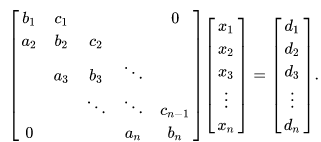


Just like Gaussian Elimination, the TMDA proceeds with the <font color='blue'> forward sweep </font> which results in a last equation having just one unknown leading to a solution of $x_n$.  This is followed by a <font color='red'> reverse sweep (backward substituion) </font> where the estimated $x_{i+1}$ value is used to compute the unknown $x_i$.  

<h3> <font color='blue'> Forward Sweep </font> </h3>

The forward sweep perform row operations wherein the pivoting row is modified and subtracted from other equations to eliminate all but one unknown $x_n$.  These operations can be succinctly summarized as follows:

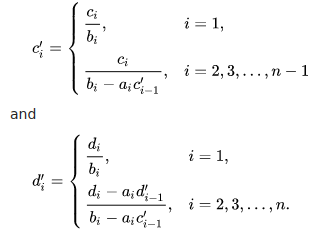

Where $c'_i$ and $d'_i$ are modified coefficients for c and d in the original matrix. Notice that b and a coefficients are not modified in this process (as they are eliminated).

<h3> <font color='blue'> Reverse Sweep (Back-substitution) </font> </h3>

The completion of the forward sweep results in a value of $x_n$.  This value can be used to compute the value of $x_{n-1}$ which in turn can be used to obtain $x_{n-2}$ and so on using the transformed coefficients as follows:  

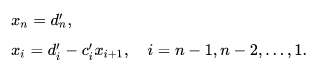

<h3> <font color='blue'> Python Implementation </font> </h3>

In [1]:
# Python Function to Implement Thomas Algorithm
# Venki Uddameri

# Step 1: Import Libraries
import numpy as np

# Function for TMDA Algorithm
def thomas(a,b,c,d):
    """ A is the tridiagnonal coefficient matrix and d is the RHS matrix"""
    N = len(a)
    cp = np.zeros(N,dtype='float64') # store tranformed c or c'
    dp = np.zeros(N,dtype='float64') # store transformed d or d'
    X = np.zeros(N,dtype='float64') # store unknown coefficients
    
    # Perform Forward Sweep
    # Equation 1 indexed as 0 in python
    cp[0] = c[0]/b[0]  
    dp[0] = d[0]/b[0]
    # Equation 2, ..., N (indexed 1 - N-1 in Python)
    for i in np.arange(1,(N),1):
        dnum = b[i] - a[i]*cp[i-1]
        cp[i] = c[i]/dnum
        dp[i] = (d[i]-a[i]*dp[i-1])/dnum
    
    # Perform Back Substitution
    X[(N-1)] = dp[N-1]  # Obtain last xn 

    for i in np.arange((N-2),-1,-1):  # use x[i+1] to obtain x[i]
        X[i] = (dp[i]) - (cp[i])*(X[i+1])
    
    return(X)

<h3> <font color='blue'> Illustrative Example </font> </h3>

Use the thomas function to solve the system of equations shown in the matrix form below:

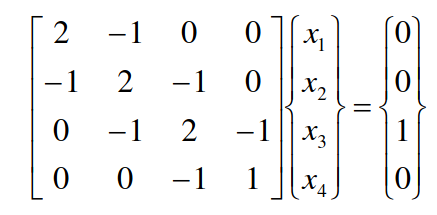

In [2]:
# Main Program
#step 1: Create Coefficient and LHS matrices store (a,b,c,d) seperately
a = [0,-1,-1,-1]
b = [2,2,2,1]
c = [-1,-1,-1,0]
d = [0,0,1,0]

# Call thomas function
x = thomas(a,b,c,d)


In [ ]:
# Print x
print('The values of x are: ',x)

The values of x are:  [1. 2. 3. 3.]


<h3> <font color='blue'> Closing Remarks </font> </h3>

Tridiagnonal matrix algorithm (TMDA) or the Thomas Algorithm is an efficient way to solve systems of equations whose coefficient matrix is tridiagonal.  This approach comes in handy when solving $2^{nd}$ Order ODEs (Boundary Value Problems) as well as 1D parabolic partial differential equations such those depicting the flow of heat, mass and momentum in natural and engineered systems.  Understanding this algorithm is therefore beneficial to engineers. 